In [20]:
import matplotlib.pyplot as plt

In [1]:
# ==========================================================
# Load Dataset with Target
# ==========================================================

from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed/BTCUSDT/BTCUSDT_1m_target.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["open_time", "close_time"]
)

In [2]:
# ==========================================================
# Preview Data
# ==========================================================

df.head(10)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,target
0,2025-01-01 00:00:00,93576.00,93610.93,93537.50,93610.93,8.21827,2025-01-01 00:00:59.999,7.689788e+05,2631,3.95157,369757.326529,0,1
1,2025-01-01 00:01:00,93610.93,93652.00,93606.20,93652.00,12.14029,2025-01-01 00:01:59.999,1.136551e+06,1273,4.08887,382791.500172,0,1
2,2025-01-01 00:02:00,93652.00,93702.15,93635.98,93702.15,11.60597,2025-01-01 00:02:59.999,1.087101e+06,1095,5.86840,549682.868570,0,0
3,2025-01-01 00:03:00,93702.14,93702.15,93654.48,93677.98,8.72958,2025-01-01 00:03:59.999,8.177203e+05,1461,2.48203,232486.113080,0,0
4,2025-01-01 00:04:00,93677.98,93677.99,93659.92,93661.20,5.24749,2025-01-01 00:04:59.999,4.915570e+05,988,0.48880,45786.251963,0,1
5,2025-01-01 00:05:00,93661.20,93678.02,93661.20,93678.01,5.08788,2025-01-01 00:05:59.999,4.766015e+05,382,4.53644,424947.267294,0,0
6,2025-01-01 00:06:00,93678.01,93678.02,93600.00,93632.05,30.37050,2025-01-01 00:06:59.999,2.843672e+06,1787,2.16303,202505.391606,0,0
7,2025-01-01 00:07:00,93632.04,93634.27,93612.00,93612.01,13.39197,2025-01-01 00:07:59.999,1.253876e+06,778,6.16177,576920.902274,0,0
8,2025-01-01 00:08:00,93612.00,93612.01,93604.86,93611.84,10.73540,2025-01-01 00:08:59.999,1.004932e+06,767,2.18287,204331.472160,0,0
9,2025-01-01 00:09:00,93611.99,93611.99,93607.09,93607.10,12.36010,2025-01-01 00:09:59.999,1.157039e+06,451,1.62350,151975.257868,0,0


In [3]:
# ==========================================================
# drop unnecessary columns
# ==========================================================

df.drop(columns=["close_time"], inplace=True)
df.drop(columns=["ignore"], inplace=True)

In [8]:
df.head(3)

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,target
0,2025-01-01 00:00:00,93576.00,93610.93,93537.50,93610.93,8.21827,7.689788e+05,2631,3.95157,369757.326529,1
1,2025-01-01 00:01:00,93610.93,93652.00,93606.20,93652.00,12.14029,1.136551e+06,1273,4.08887,382791.500172,1
2,2025-01-01 00:02:00,93652.00,93702.15,93635.98,93702.15,11.60597,1.087101e+06,1095,5.86840,549682.868570,0


In [13]:
print(df["target"].value_counts())

print(f"Total number of rows in the dataset: {len(df)}")

target
0    10464
1     9696
Name: count, dtype: int64
Total number of rows in the dataset: 20160


In [14]:
print(df.isnull().sum())

open_time                 0
open                      0
high                      0
low                       0
close                     0
volume                    0
quote_asset_volume        0
number_of_trades          0
taker_buy_base_volume     0
taker_buy_quote_volume    0
target                    0
dtype: int64


In [15]:
df["hour"] = df["open_time"].dt.hour
df["minute"] = df["open_time"].dt.minute
df["day"] = df["open_time"].dt.day
df["day_of_week"] = df["open_time"].dt.dayofweek   # Monday = 0
df["month"] = df["open_time"].dt.month
df["week"] = df["open_time"].dt.isocalendar().week.astype(int)

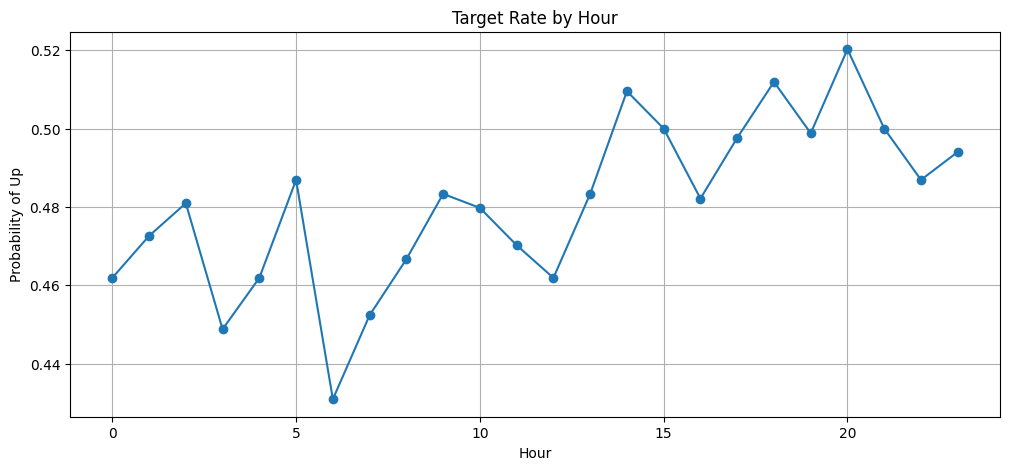

In [21]:
plt.figure(figsize=(12,5))

plt.plot(hour_analysis["hour"], hour_analysis["mean"], marker="o")

plt.xlabel("Hour")
plt.ylabel("Probability of Up")
plt.title("Target Rate by Hour")
plt.grid(True)

plt.show()

<Figure size 1200x500 with 0 Axes>

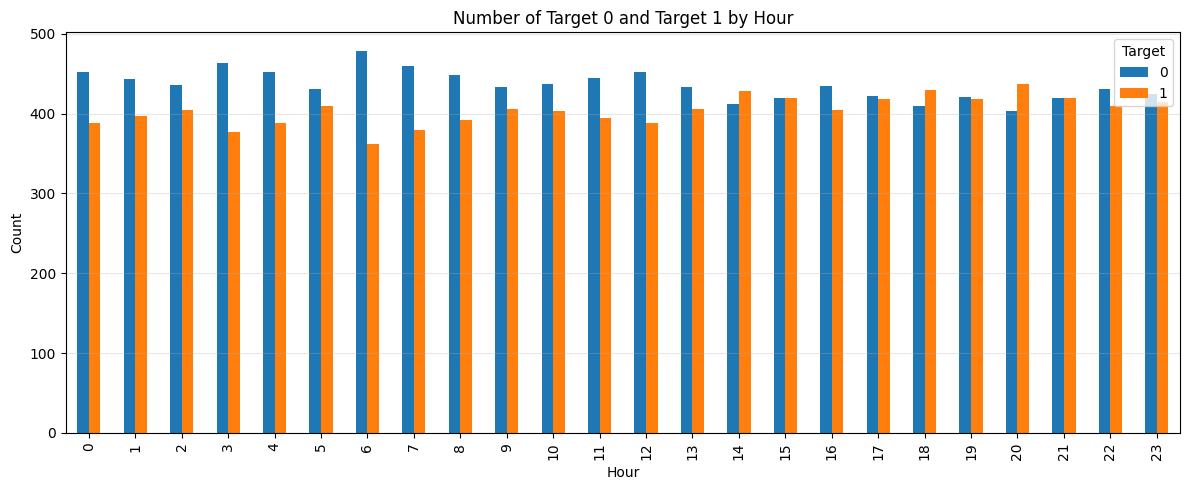

In [23]:
import matplotlib.pyplot as plt

# Đếm số lượng target theo từng giờ
hour_target = (
    df.groupby(["hour", "target"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(12, 5))

hour_target.plot(
    kind="bar",
    stacked=False,
    figsize=(12, 5)
)

plt.title("Number of Target 0 and Target 1 by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend(title="Target")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Số lượng target = 0 và target = 1 theo từng giờ
hour_target_table = (
    df.groupby(["hour", "target"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "Target_0", 1: "Target_1"})
)

hour_target_table

target,Target_0,Target_1
hour,,
0,452,388
1,443,397
2,436,404
3,463,377
4,452,388
5,431,409
6,478,362
7,460,380
8,448,392


In [25]:
table = pd.crosstab(df["hour"], df["target"])

table

target,0,1
hour,,
0,452,388
1,443,397
2,436,404
3,463,377
4,452,388
5,431,409
6,478,362
7,460,380
8,448,392


In [26]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(table)

print(f"Chi-square : {chi2:.4f}")
print(f"p-value    : {p_value:.6f}")
print(f"DOF        : {dof}")

Chi-square : 36.0809
p-value    : 0.040475
DOF        : 23


In [28]:
import numpy as np
from scipy.stats import chi2_contingency

table = pd.crosstab(df["hour"], df["target"])

chi2, p, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
r, c = table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r - 1, c - 1))))

print(f"Cramer's V = {cramers_v:.4f}")

Cramer's V = 0.0423
